California Housing model (Linear Regression and Random Forest regression via sklearn)

In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

Importing the data. Source: https://www.kaggle.com/datasets/nalisha/california-housing-prices-dataset-clean-and-ml/data

In [4]:
data = pd.read_csv("housing.csv")
display(data.head())

print("-----Data Shape----\n")
print(data.shape)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


-----Data Shape----

(20640, 10)


Get some key features of the data.

In [6]:
print("\n-----Description-----\n")
display(data.describe())

print("\n----Information-----\n")
display(data.info())

print("\n-----Columns Name------\n")
data_1 = pd.DataFrame(data.columns, columns = ["Columns Name"])
display(data_1)



-----Description-----



,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000



----Information-----

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


None


-----Columns Name------



,Columns Name
0,longitude
1,latitude
2,housing_median_age
3,total_rooms
4,total_bedrooms
5,population
6,households
7,median_income
8,median_house_value
9,ocean_proximity


Notice, for now, that there are miss data in the total_bedrooms column. We must address this.

For now, as we want to predict the median_house_value, let us first check if it has a good distribution for a better model.

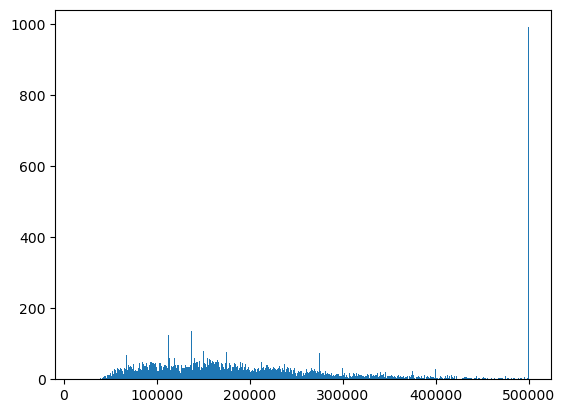

In [8]:
y0 = data["median_house_value"]
plt.hist(y0.to_numpy(), bins=1000)
plt.savefig("images/median_house_value_distribution.png", dpi=150, bbox_inches='tight') 
plt.show()

Now, we see some odd data around 500000. This doesn't look coherent to the overall data. I found that, by filtering them out, I get much better model. Let us filter these odd data out.

In [10]:
data_filter = data[data["median_house_value"] < 495000]
data_filter.shape

(19629, 10)

Now, we see some odd data around 500000. This doesn't look coherent to the overall data. I found that, by filtering them out, I get much better model. Let us filter these odd data out.

In [12]:
print("\n-----Before Missing Value------\n")
display(data_filter.isnull().sum())

data_filter["total_bedrooms"].fillna(data_filter["total_bedrooms"].median(), inplace=True)
print("\n-----After Missing Value------\n")
display(data_filter.isnull().sum())


-----Before Missing Value------



longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        200
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


-----After Missing Value------



/var/folders/yh/z6n8z11940qcsd35tldkmvvst3wtn3/T/ipykernel_16860/2158555487.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_filter["total_bedrooms"].fillna(data_filter["total_bedrooms"].median(), inplace=True)


longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

Check again if the data makes sense now.

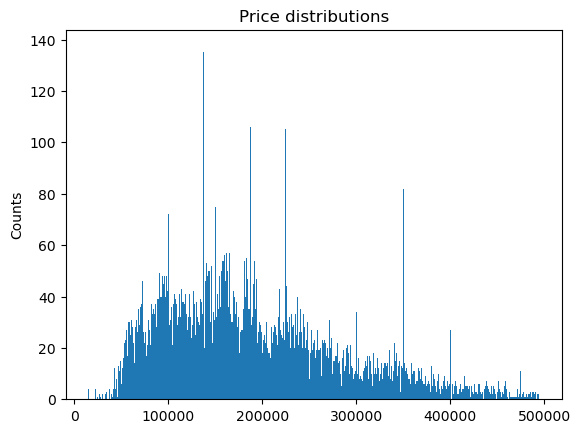

In [14]:
y = data_filter["median_house_value"]
X0 = data_filter.drop(["median_house_value"], axis =1)

plt.hist(y.to_numpy(), bins=1000)
plt.title("Price distributions")
plt.ylabel("Counts")
plt.savefig("images/median_house_value_distribution_filtered.png", dpi=150, bbox_inches='tight') 
plt.show()

Now, we want to index the data for the ocean proximity category. But first, we want to check how many unique values are there for ocean category column.

In [16]:
print("\n------unique Value-------\n")
display(X0.filter(like = "ocean_proximity").nunique())


------unique Value-------



ocean_proximity    5
dtype: int64

As there are 5 categories in this, we can index them sufficiently as follows.

In [18]:
X = pd.get_dummies(X0, columns = ["ocean_proximity"], drop_first = True)
display(X.filter(like = "ocean_proximity"))

,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,0,0,1,0
1,0,0,1,0
2,0,0,1,0
3,0,0,1,0
4,0,0,1,0
...,...,...,...,...
20635,1,0,0,0
20636,1,0,0,0
20637,1,0,0,0
20638,1,0,0,0


Note, that the last missing one is "less than 1H from ocean". This corresponds to when the all 4 categories above are 0. Here are some plots vs the price and the histograms for the distribution of the data for each categories.

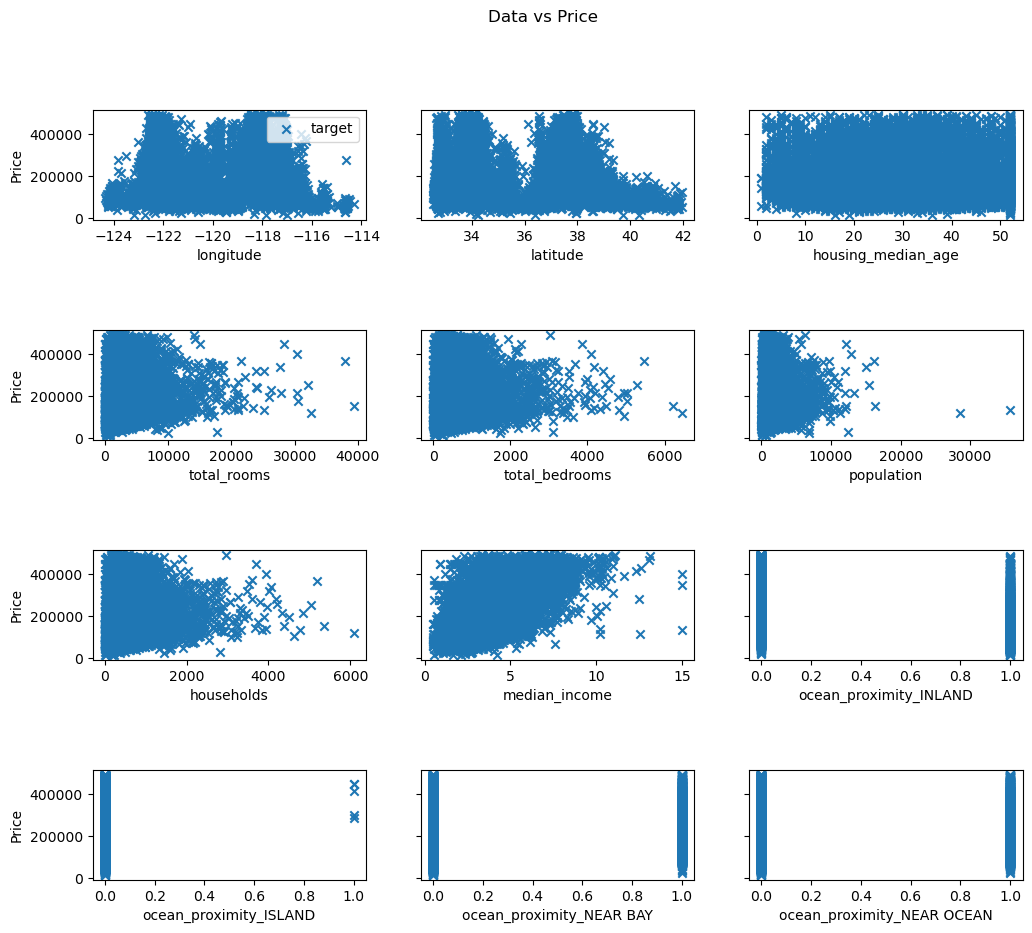

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


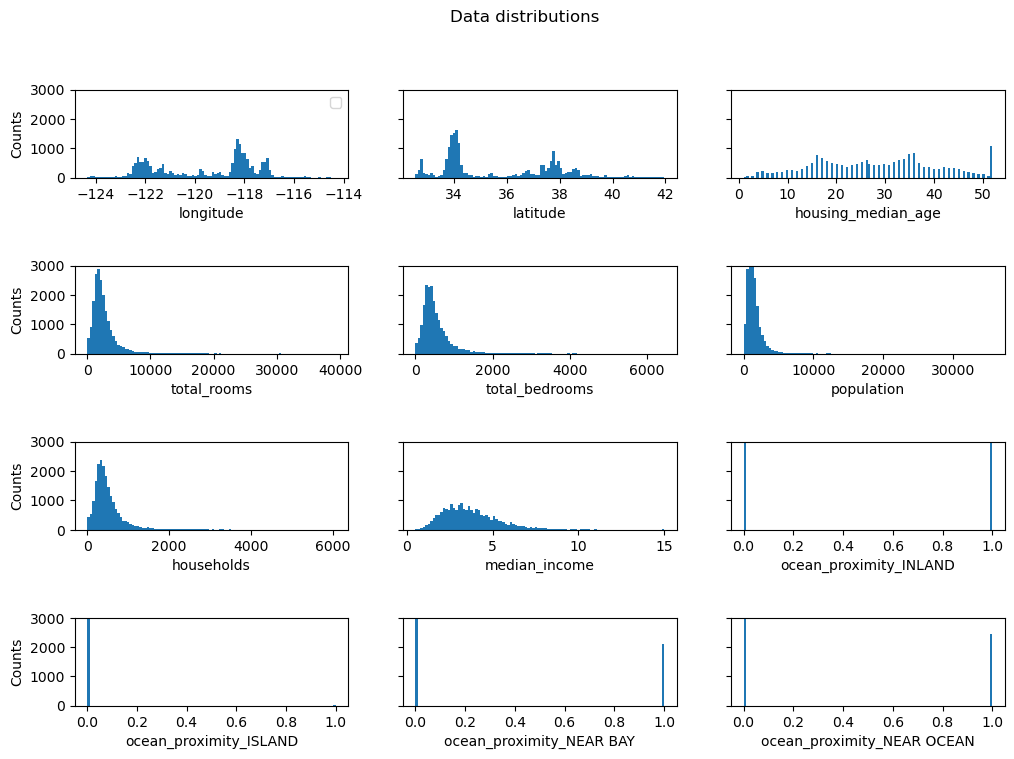

In [20]:
fig, ax = plt.subplots(4, 3, figsize=(12, 10), sharey=True)
plt.subplots_adjust(hspace=1)
for j, i in enumerate(range(0, 12)):  # j = 0..5, i = 3..8
    row = j//3
    col = j%3
    # Plot target
    ax[row, col].scatter(X.iloc[:, i].to_numpy(), y.to_numpy(), label='target', marker = 'x')
    ax[row, col].set_xlabel(X.columns[i])
    ax[row,0].set_ylabel("Price")

ax[0,0].legend()

fig.suptitle("Data vs Price")
plt.savefig("images/data_vs_price.png", dpi=150, bbox_inches='tight') 
plt.show()

fig, ax = plt.subplots(4, 3, figsize=(12, 8), sharey=True)
plt.subplots_adjust(hspace=1)
plt.ylim(0,3000)
for j, i in enumerate(range(0, 12)):
    row = j//3
    col = j%3
    # Plot histogram
    ax[row, col].hist(X.iloc[:, i].to_numpy(), bins=100)
    ax[row, col].set_xlabel(X.columns[i])
    ax[row,0].set_ylabel("Counts")

ax[0,0].legend()
fig.suptitle("Data distributions")
plt.savefig("images/data_distribution.png", dpi=150, bbox_inches='tight') 
plt.show()

To buit the learning model, we now want to:

First, we want to split the data into training set and testing set (70:30 in for my model). This way, we can produce the model via the training set and test it with the testing set.

Second, for faster convergence, we want to rescale the data. I this model, I choose the StandarScaler (respect to its mean and standard deviation).

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)  
X_test_norm = scaler.transform(X_test) 

Now, we can fit the model.

In [24]:
sgdr = SGDRegressor(max_iter=2000)
sgdr.fit(X_train_norm, y_train)
print(sgdr)
print(f"number of iterations completed: {sgdr.n_iter_}, number of weight updates: {sgdr.t_}")
print(f"Converged: {sgdr.n_iter_ < sgdr.max_iter}")

SGDRegressor(max_iter=2000)
number of iterations completed: 20, number of weight updates: 274801.0
Converged: True


We can check the parameters here.

In [26]:
b_norm = sgdr.intercept_
w_norm = sgdr.coef_
print(f"model parameters:                   w: {w_norm}, b:{b_norm}")

model parameters:                   w: [-46738.54299327 -46832.30773767  11435.62184686 -14728.63450703
  29403.11673808 -32562.07337558  19233.55202616  59345.23000071
 -18724.48545299    509.58072107  -2362.81090688   2307.16195775], b:[191393.89519386]


Note that two are two ways you can make the prediction. Both ways should agree.

In [28]:
# make a prediction using sgdr.predict()
y_pred_sgd = sgdr.predict(X_test_norm)
# make a prediction using w,b. 
y_pred = np.dot(X_test_norm, w_norm) + b_norm  
print(f"prediction using np.dot() and sgdr.predict match: {(y_pred == y_pred_sgd).all()}")

prediction using np.dot() and sgdr.predict match: True


Now, let us test the prediction of trained model and the testing data.

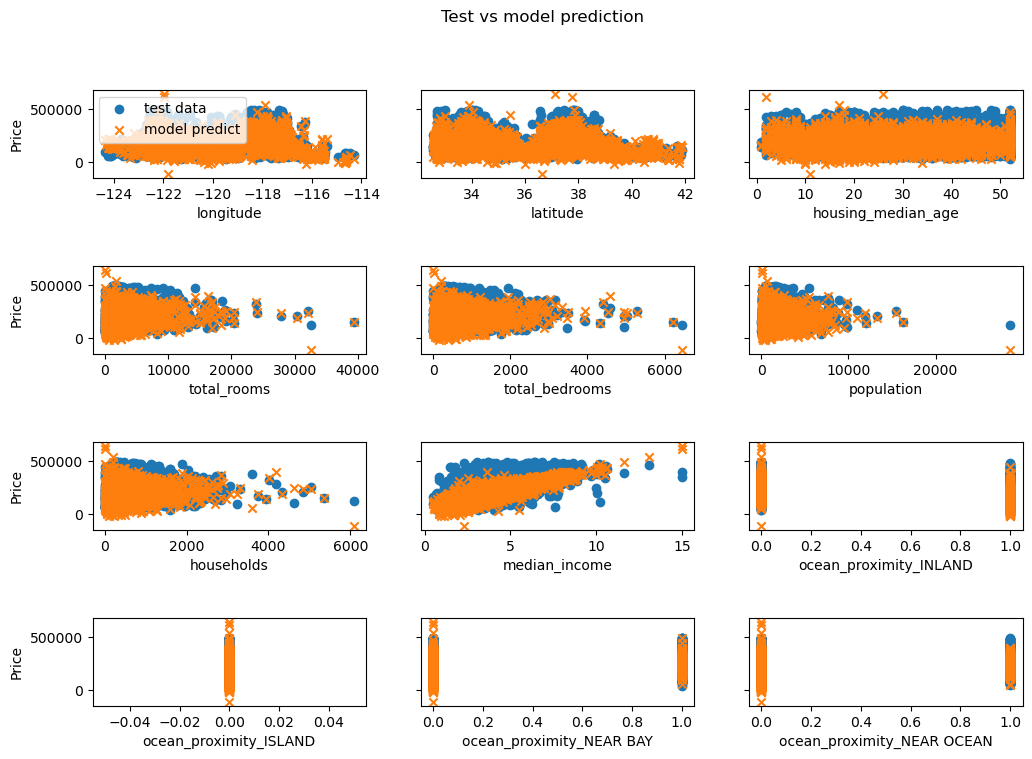

In [30]:
fig, ax = plt.subplots(4, 3, figsize=(12, 8), sharey=True)
plt.subplots_adjust(hspace=1)
for j, i in enumerate(range(0, 12)):  # j = 0..5, i = 3..8
    row = j//3
    col = j%3
    # Plot target
    ax[row, col].scatter(X_test.iloc[:, i].to_numpy(), y_test.to_numpy(), label='test data')
    # plot prediction
    ax[row, col].scatter(X_test.iloc[:, i], y_pred, label='model predict', marker = 'x')
    ax[row, col].set_xlabel(X_train.columns[i])
    ax[row,0].set_ylabel("Price")

ax[0,0].legend()

fig.suptitle("Test vs model prediction")
plt.savefig("images/Test_vs_model.png", dpi=150, bbox_inches='tight') 
plt.show()

That looks good. We can also quanlitatively check to see how well the model matches the data using the R2 score, given by:

In [32]:
r2_score(y_test, y_pred_sgd)

0.6160920082394641

Let's try with Random forest model

In [69]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=40)
rf.fit(X_train_norm, y_train)
y_pred_rf = rf.predict(X_test_norm)
print(r2_score(y_test, y_pred_rf)) 

0.7900995895205284


It is seen that the R2 score is improved from the liner regresstion model and it can also be optimised with respect to the number of "trees". Let's see if we can optimise this model. Basically, we can use GridSearchCv to optimise;however, I find that it is too slow. So, I use RandomisedSerach instead.

In [101]:
#from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [200, 400, 500],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10]
}

rf_base = RandomForestRegressor(random_state=40)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_grid,
    n_iter=15,          # only tries 15 random combinations instead of all 27
    cv=5, # 5-fold cross validation
    scoring="r2", # optimise for R2
    n_jobs=-1, # use all CPU cores to speed it up
    random_state=42 
)

random_search.fit(X_train_norm, y_train)

print("Best parameters:", random_search.best_params_)
print("Best R2 score:", random_search.best_score_)

Best parameters: {'n_estimators': 500, 'min_samples_split': 2, 'max_depth': 20}
Best R2 score: 0.7843435148363775


Extracting the best configuration.

In [103]:
best_rf = random_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test_norm)
print("Test R2:", r2_score(y_test, y_pred_tuned))

Test R2: 0.7907849416399042


The best model is only slightly better R2 score than the "naive" model. Now, let's look into the Random Forest model and how each feature contributes to the model via Feature importance.

                       Feature  Importance
7                median_income    0.437063
8       ocean_proximity_INLAND    0.161788
0                    longitude    0.117959
1                     latitude    0.110448
2           housing_median_age    0.047855
5                   population    0.036515
3                  total_rooms    0.028898
4               total_bedrooms    0.025657
6                   households    0.021378
11  ocean_proximity_NEAR OCEAN    0.010724
10    ocean_proximity_NEAR BAY    0.000979
9       ocean_proximity_ISLAND    0.000735


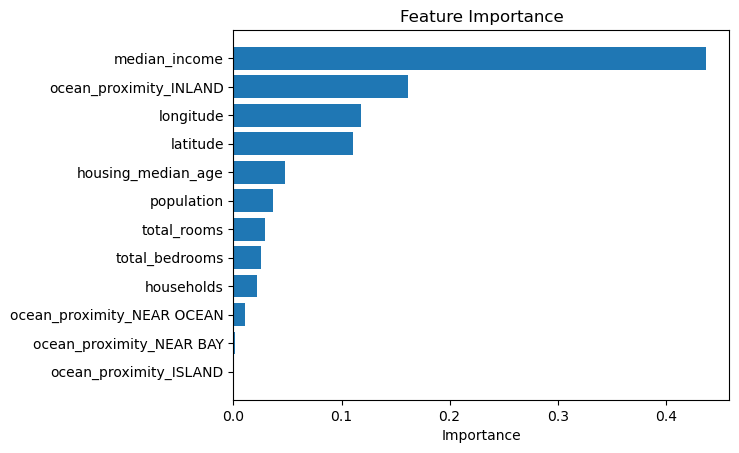

In [107]:
importances = best_rf.feature_importances_
feature_names = X_train.columns


importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print(importance_df)

plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.savefig("images/feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

Let's compare the model with the test data.

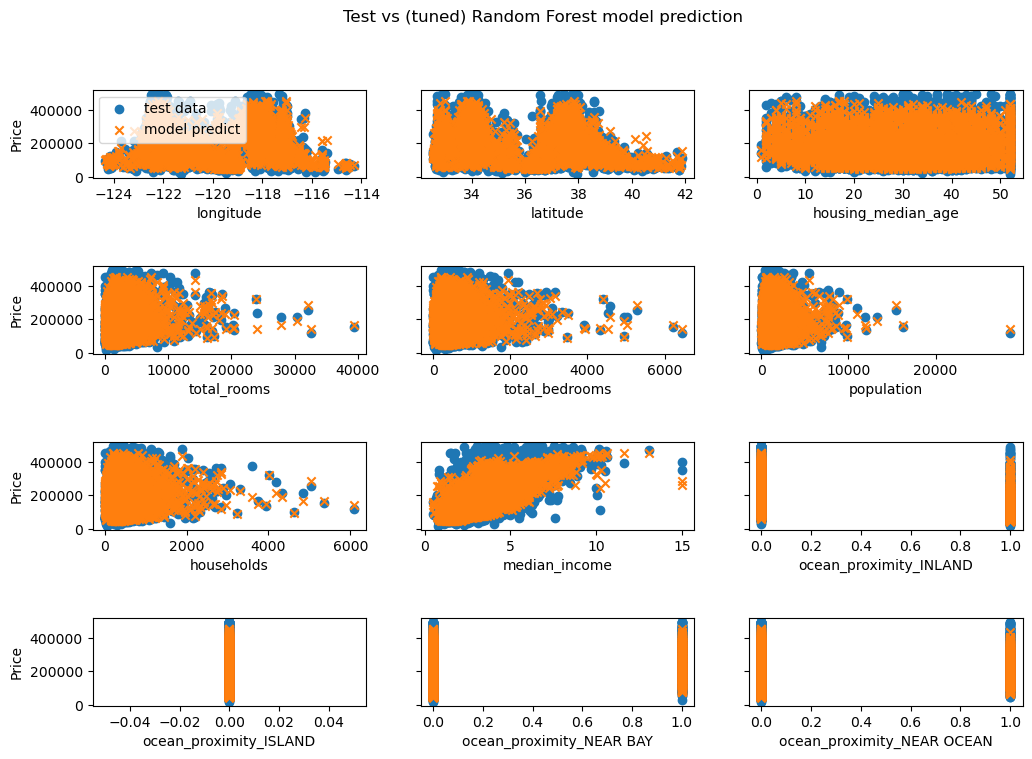

In [109]:
fig, ax = plt.subplots(4, 3, figsize=(12, 8), sharey=True)
plt.subplots_adjust(hspace=1)
for j, i in enumerate(range(0, 12)):  # j = 0..5, i = 3..8
    row = j//3
    col = j%3
    # Plot target
    ax[row, col].scatter(X_test.iloc[:, i].to_numpy(), y_test.to_numpy(), label='test data')
    # plot prediction
    ax[row, col].scatter(X_test.iloc[:, i], y_pred_tuned, label='model predict', marker = 'x')
    ax[row, col].set_xlabel(X_train.columns[i])
    ax[row,0].set_ylabel("Price")

ax[0,0].legend()

fig.suptitle("Test vs (tuned) Random Forest model prediction")
plt.savefig("images/Test_vs_model_rf.png", dpi=150, bbox_inches='tight') 
plt.show()

Conclusion

I performed the Linear Regression and Random Forest model to predict the California housing median price. I first cleaned the data by filtering out some extreme data and replacing the missing data and replace it with the corresponding categorical median values.

Using Linear Regression to train the data yields the R2 score of 61.5% (how well the model can fit the data), while the Random Forest with random search gives 79.1%. Since the relationship of the data features and the house median price are non-linear in nature, the Random Forest model thus performs better than the Linear Regression model. I also found that the median income category contributes the most to the model with 43.6%. 

To improve a better prediction, one may need to consider further optimising the Random Forest model. However, this comes with a more complexity in computation.